# Sentiment Analysis
### Context
#### This is the sentiment140 dataset. It contains 1,600,000 tweets extracted using the twitter api . The tweets have been annotated (0 = negative, 4 = positive) and they can be used to detect sentiment .

### Content
#### It contains the following 6 fields:

#### target: the polarity of the tweet (0 = negative, 2 = neutral, 4 = positive)

#### ids: The id of the tweet ( 2087)

#### date: the date of the tweet (Sat May 16 23:58:44 UTC 2009)

#### flag: The query (lyx). If there is no query, then this value is NO_QUERY.

#### user: the user that tweeted (robotickilldozr)

#### text: the text of the tweet (Lyx is cool)

In [2]:
!pip install numpy pandas scipy seaborn matplotlib scikit-learn nltk
import pandas as pd
import numpy as np 
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from scipy import stats
from IPython.display import display
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer



# Load dataset
file_path = r"C:\Users\npate\pythonlab\Scripts\training.1600000.processed.noemoticon.csv"  # Update with your file path
columns = ["target", "id", "date", "flag", "user", "text"]
df = pd.read_csv(file_path, encoding="latin-1", names=columns)

# Keep only necessary columns
# df = df[["target", "text"]]

# Convert target labels: 0 (negative) → 0, 4 (positive) → 1
# df["target"] = df["target"].replace({0: 0, 4: 1})



## Data Cleaning & Preprocessing
#### We'll remove unnecessary characters, lowercase the text, and tokenize words
#### Lowercasing – Convert all text to lowercase to maintain consistency.

#### Removing Punctuation & Special Characters – These don’t add value to sentiment analysis.

#### Tokenization – Split sentences into individual words.

#### Removing Stopwords – Words like "the," "is," and "at" don’t contribute much meaning.

#### Lemmatization/Stemming – Convert words to their root form (e.g., "running" → "run").

In [4]:
# Understanding data
df.shape


(1600000, 6)

### We found that the dataset consists of 1,600,000 rows and 6 column

In [8]:
df.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


## Data Preprocessing and Cleaning¶
#### Now, let's move on to data preprocessing and cleaning to ensure our dataset is well-structured and ready for analysis and modeling.

#### "First, we need to focus on the most relevant features in our dataset: 'text' and 'target'. The rest of the columns are not important.

##### 'textt' is the independent feature (input) that we'll use to predict sentiment.
##### 'target' is the target variable (output) that represents the sentiment classification."

In [14]:
df = df[["text", "target"]].copy()
df.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


## Cleaning Tweets:¶
### To improve the quality of our dataset, we need to clean the tweets by removing unnecessary elements like links, special characters, and stopwords. Let's go through the function step by step:

### 1. Importing Required LibrariesWe first import the necessary libraries for text processing:

#### re: For regular expressions, which help in text cleaning.
#### nltk: A powerful library for natural language processing (NLP).
#### stopwords from nltk.corpus: A list of common words (e.g., "the", "is", "and") that don't add much meaning.
#### PorterStemmer: A stemming algorithm that reduces words to their root form (e.g., "running" → "run").
#### STOPWORDS from wordcloud: Another set of common words to remove.

### 2. Downloading and Defining Stopwords:

#### We download the stopwords list using nltk.download('stopwords').
#### We create a set of stopwords for faster lookups.
#### We add extra stopwords: "amp", "rt", "lt", and "gt" (often seen in tweets but aren't meaningful). 



In [17]:
#!C:\Users\npate\pythonlab\Scripts\pip install --upgrade --force-reinstall nltk

In [19]:

import re
import nltk
import string
#!C:\Users\npate\pythonlab\Scripts\pip install --upgrade --force-reinstall wordcloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import STOPWORDS

nltk.download('stopwords')

stop_words = set(stopwords.words('english')) 
stop_words.update(["amp", "rt", "lt", "gt"])  

stemmer = PorterStemmer()  

def clean_text(text):
    text = text.lower()  
    text = re.sub(r"https?://\S+", "", text)  
    text = re.sub(r"@\w+|#", "", text)  
    text = re.sub(r"[^\w\s]|[\d]", "", text)  
    text = " ".join([stemmer.stem(word) for word in text.split() if word not in stop_words])
    return text

df["clean_text"] = df["text"].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\npate\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,target,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0,awww that bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,0,upset cant updat facebook text might cri resul...
2,@Kenichan I dived many times for the ball. Man...,0,dive mani time ball manag save rest go bound
3,my whole body feels itchy and like its on fire,0,whole bodi feel itchi like fire
4,"@nationwideclass no, it's not behaving at all....",0,behav im mad cant see


## Exploratory Data Analysis - EDA¶
#### After cleaning the data, the next step is to understand its characteristics using statistical analysis and visualizations.

#### "First, we'll convert the sentiment labels to their original meanings for better readability:

#### 0 → Negative 😠
#### 4 → Positive 😊

In [22]:
df["target"] = df["target"].replace({0: "Negative", 4: "Positive"})
df.head()

,text,target,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative,awww that bummer shoulda got david carr third day
1,is upset that he can't update his Facebook by ...,Negative,upset cant updat facebook text might cri resul...
2,@Kenichan I dived many times for the ball. Man...,Negative,dive mani time ball manag save rest go bound
3,my whole body feels itchy and like its on fire,Negative,whole bodi feel itchi like fire
4,"@nationwideclass no, it's not behaving at all....",Negative,behav im mad cant see


### Sentiment Distribution
#### Objective: Determine whether the dataset is balanced or biased toward a particular sentiment.
#### We'll visualize the count of each sentiment class using pie chart

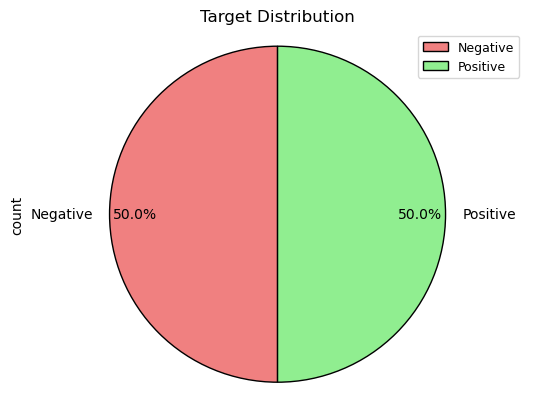

In [25]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="pie", 
                                    autopct='%1.1f%%',
                                    pctdistance=0.85, 
                                    startangle=90, 
                                    colors=["lightcoral", "lightgreen"],  
                                    wedgeprops={'edgecolor': 'black'}) 

plt.title('Target Distribution')
plt.axis('equal')  
plt.legend(labels=df["target"].value_counts().index, 
           loc='upper right', fontsize=9)
plt.show()

## 2. Most Common Words in Each Sentiment (Word Clouds)

#### Objective: Identify words commonly associated with positive and negative sentiments.
#### A word cloud is a great way to see the most frequent words in each sentiment category.
#### This helps us understand what kind of words contribute to positive or negative emotions.

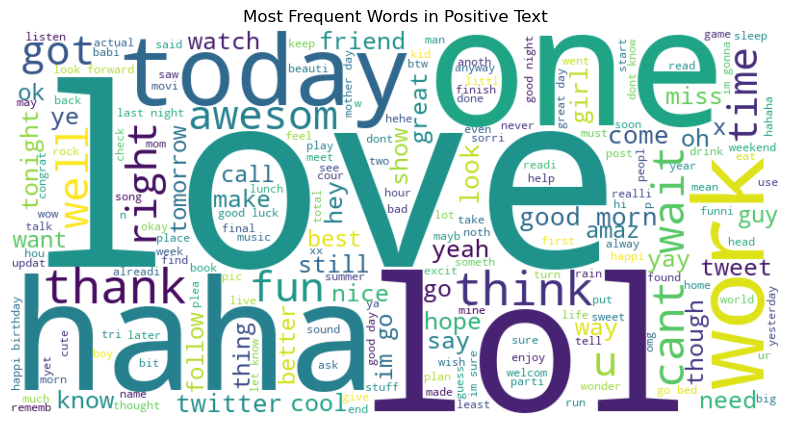

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_words = " ".join(df[df["target"] == "Positive"]["clean_text"])
negative_words = " ".join(df[df["target"] == "Negative"]["clean_text"])

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(positive_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Positive Text")
plt.show()

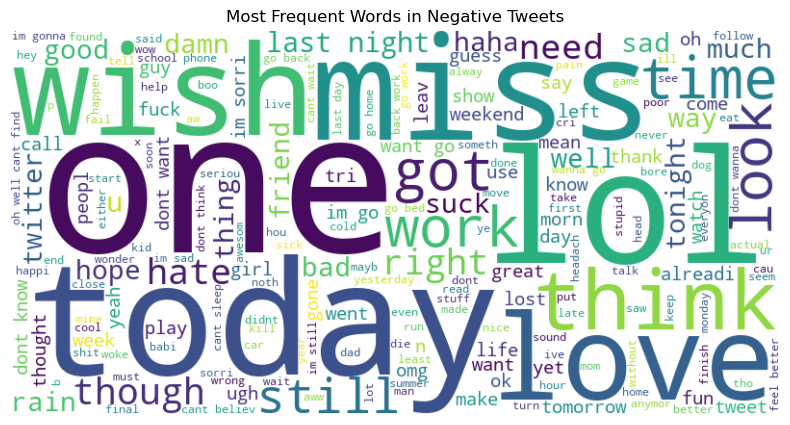

In [30]:
# Same for negative text

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(negative_words)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Negative Tweets")
plt.show()

### Note: After displaying the results, you'll notice that some words are common across both positive and negative sentiment classes. However, their frequency of occurrence varies between the two classes.

### 3. Tweet Length Distribution

#### Objective: Analyze the average length of textss and its impact on target.
##### We'll visualize the result using histogram and bar chart
##### First, we need to add a new feature to our dataset: the length of the textss.

In [33]:
df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))
df.head()

,text,target,clean_text,text_length
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative,awww that bummer shoulda got david carr third day,9
1,is upset that he can't update his Facebook by ...,Negative,upset cant updat facebook text might cri resul...,12
2,@Kenichan I dived many times for the ball. Man...,Negative,dive mani time ball manag save rest go bound,9
3,my whole body feels itchy and like its on fire,Negative,whole bodi feel itchi like fire,6
4,"@nationwideclass no, it's not behaving at all....",Negative,behav im mad cant see,5


#### Let's filter the data to check if there are any tweets with a length of zero after cleaning them using the clean_tweet function. We'll then compare these tweets with their original versions before cleaning."

In [37]:
zero_len = df[df["text_length"]==0][["text" ,"clean_text","text_length"]]
display(zero_len.shape)
zero_len.head()

(7090, 3)

,text,clean_text,text_length
208,@mandayyy,,0
249,@mandayyy,,0
282,@ITS_NEMESIS -------,,0
398,@danadearmond,,0
430,@anistorm,,0


#### After displaying the results, we will notice that there are 7090 tweets with a length of zero after cleaning, meaning they are empty. Upon examining the original content, we can see that most of these tweets only contained user mentions (e.g., @user), which were removed during the cleaning process.

In [40]:
# Now, we will remove the empty tweets as well as any duplicates from the dataset.
df = df[df["text_length"] != 0].reset_index(drop = True)
df = df.drop_duplicates(subset=['clean_text'], keep='first')
display(df.shape)

(1475147, 4)

#### Now, let's calculate the average tweet length for both positive and negative sentiments.

In [43]:
text_len = df.groupby(["target"]).agg(
   mean = ("text_length", "mean")
)

text_len = text_len.transpose()
text_len

target,Negative,Positive
mean,7.694833,7.345752


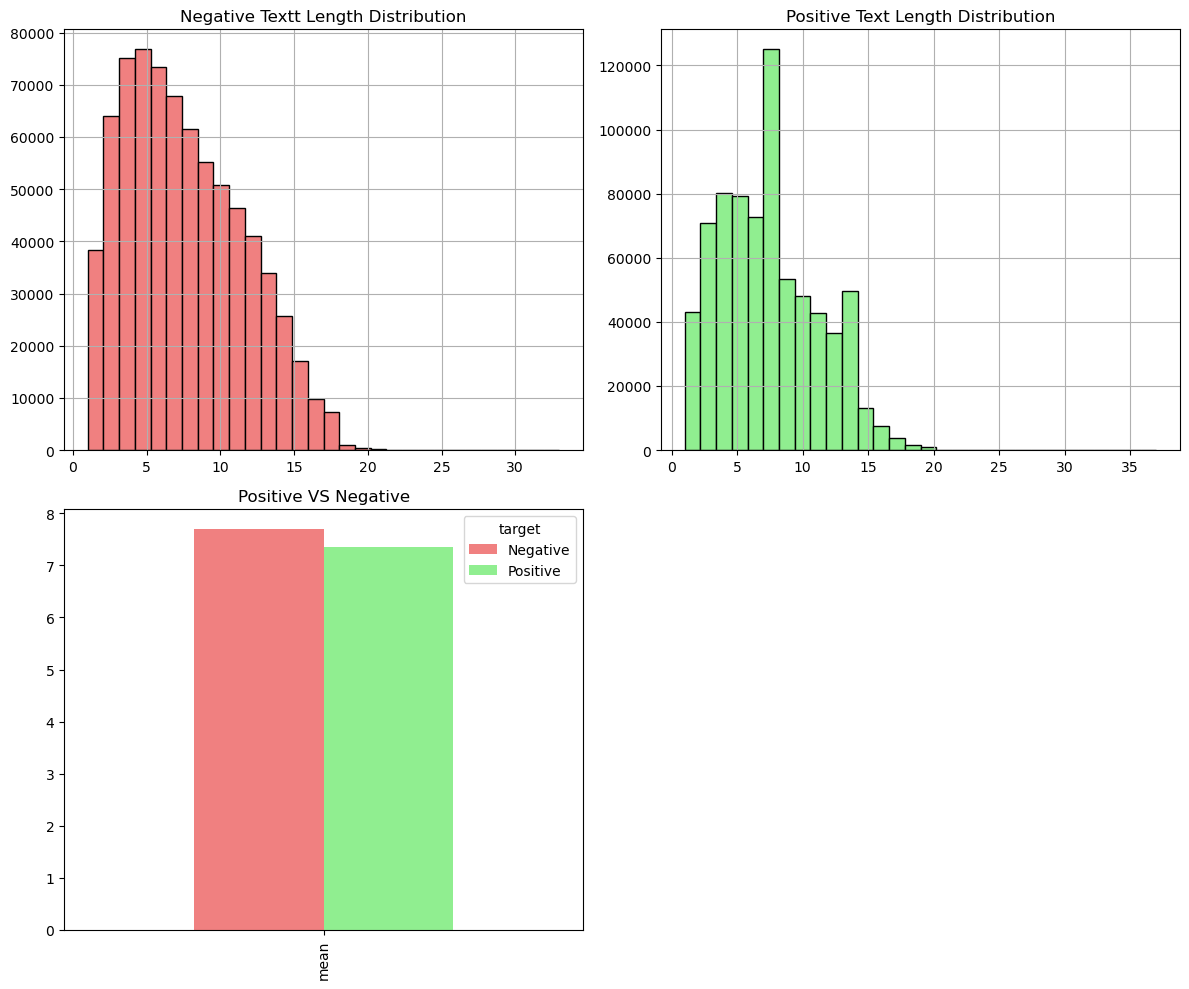

In [45]:
# Plotting histogram

fig, axes = plt.subplots(2, 2, figsize=(12, 10))


df[df["target"]=="Negative"]["text_length"].hist(color="lightcoral", edgecolor="black", ax=axes[0, 0], bins=30)
df[df["target"]=="Positive"]["text_length"].hist(color="lightgreen", edgecolor="black", ax=axes[0, 1], bins=30)
text_len.plot(kind="bar", color = ("lightcoral", "lightgreen"), ax = axes[1, 0] )

axes[0, 0].set_title("Negative Textt Length Distribution")
axes[0, 1].set_title("Positive Text Length Distribution")
axes[1, 0].set_title("Positive VS Negative")
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

#### After displaying the distribution using a histogram and comparing the mean tweet lengths for positive and negative sentiments with a bar chart, it is evident that negative tweets are generally longer than positive ones.

## 3. Data Modeling
#### "Data Modeling" is the next phase in our pipeline. In this stage, we build and train models that can predict sentiment based on the processed tweet text.
### Feature Extraction: Convert cleaned tweet text into numerical features using techniques such as TF-IDF, bag-of-words, or word embeddings.
### Splitting the Data: Divide the dataset into training and testing subsets to evaluate model performance.
### Model Selection: Choose a suitable algorithm (like logistic regression, SVM, or deep learning models) for sentiment classification.
### Training the Model: Fit the chosen model on the training data.
### Evaluation: Assess model performance on the test set using metrics like accuracy, precision, recall, and F1-score.

### Feature Extraction: In this stage, we will use the Bag-of-Words technique.
#### Bag-of-Words is a method for converting text data into numerical features that can be used by machine learning algorithms. The process involves:
#### Vocabulary Creation: Building a list of all unique words found in the corpus (in this case, all tweets).
#### Vectorization: Representing each tweet as a vector, where each element corresponds to the count (or frequency) of a word from the vocabulary in that tweet.
#### Simplicity and Efficiency: This technique ignores the grammar and word order, focusing solely on the occurrence of words, which makes it simple yet effective for many text classification tasks such as sentiment analysis.

In [50]:
#BoW(Bag of Words)
#from sklearn.feature_extraction.text import CountVectorizer

#cv = CountVectorizer(max_features=100000)
#X = cv.fit_transform(df["clean_text"]) 
#len(cv.get_feature_names_out())

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
x_tfidf = tfidf_vectorizer.fit_transform(df["clean_text"])  

y = df["target"].map({"Negative": 0, "Positive": 1}) 

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_tfidf, y, test_size=0.2, random_state=42)

In [51]:
# Splitting the Data to train and test

#from sklearn.model_selection import train_test_split

#x_train, x_test, y_train, y_test = train_test_split(X, y, random_state =0)

In [52]:
#Implementing LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler(with_mean=False)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=500, solver='saga')
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=500, solver='saga')

In [55]:
y_pred = model.predict(x_test_scaled)
y_pred

array([0, 1, 0, ..., 0, 1, 1], dtype=int64)

In [58]:
# Model Evaluation (LogisticRegression)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100:.4f}%')

conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)

class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 76.4183%
Confusion Matrix:
[[110506  38461]
 [ 31112 114951]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76    148967
           1       0.75      0.79      0.77    146063

    accuracy                           0.76    295030
   macro avg       0.76      0.76      0.76    295030
weighted avg       0.76      0.76      0.76    295030



In [60]:
# Implementing Naive Bayes
# Train Naïve Bayes Model
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)

# Make Predictions
y_pred = nb_model.predict(x_test)

# Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", report)

Accuracy: 74.75%
Confusion Matrix:
 [[111927  37040]
 [ 37456 108607]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75    148967
           1       0.75      0.74      0.74    146063

    accuracy                           0.75    295030
   macro avg       0.75      0.75      0.75    295030
weighted avg       0.75      0.75      0.75    295030



In [62]:
# Let's try alpha tuning to increase the accuracy
from sklearn.model_selection import GridSearchCV

# Define Hyperparameters for Tuning
param_grid = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]}  # Alpha values to test

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(x_train, y_train)

# Get Best Parameters & Accuracy
best_alpha = grid_search.best_params_['alpha']
best_score = grid_search.best_score_

print(f"Best Alpha: {best_alpha}")
print(f"Best Cross-Validation Accuracy: {best_score * 100:.2f}%")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Alpha: 10.0
Best Cross-Validation Accuracy: 74.66%


In [64]:

#Let's implement Naive Bayes again. Lets see if we get better with alpha tuning
from sklearn.naive_bayes import MultinomialNB

# Train the optimized model
nb_optimized = MultinomialNB(alpha=5.0)
nb_optimized.fit(x_train, y_train)

# Evaluate on Test Set
y_pred = nb_optimized.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy with Optimized Naïve Bayes: {acc * 100:.2f}%")


Test Accuracy with Optimized Naïve Bayes: 74.78%
